# Phase 8: Baseline Model Training (XGBoost)

This notebook trains a tuned **XGBoost baseline** on gene-level splits,
evaluates performance, computes SHAP feature importances, and runs
ablation studies to measure the contribution of each feature group.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.models.xgboost_model import XGBTuningConfig, tune_xgboost
from src.evaluation import compute_classification_metrics, select_best_threshold

print(f'Repo root: {repo_root}')

Repo root: /Users/ry7vv/Documents/Coding_Project/GenticGraduationProject


## Step 1: Load Train / Validation / Test


In [2]:
train_df = pd.read_parquet(repo_root / 'data/splits/train.parquet')
val_df = pd.read_parquet(repo_root / 'data/splits/val.parquet')
test_df = pd.read_parquet(repo_root / 'data/splits/test.parquet')

def split_summary(name, df):
    p = int((df['label'] == 1).sum())
    b = int((df['label'] == 0).sum())
    return {
        'Split': name,
        'Rows': len(df),
        'Genes': df['gene'].nunique(),
        'Pathogenic (1)': p,
        'Benign (0)': b,
        'Pathogenic %': (p / len(df)) * 100,
    }

pd.DataFrame([
    split_summary('Train', train_df),
    split_summary('Validation', val_df),
    split_summary('Test', test_df),
])

,Split,Rows,Genes,Pathogenic (1),Benign (0),Pathogenic %
0,Train,195124,10961,91329,103795,46.805621
1,Validation,43005,2349,19062,23943,44.325078
2,Test,45263,2349,22463,22800,49.627731


## Step 2: Feature Selection + Categorical Encoding

- Numeric and boolean features are passed through directly (tree-based models do not require scaling)
- Categorical columns are one-hot encoded using a train-fitted encoder
- The fitted encoder is reused for strict data to maintain consistent feature shape


In [3]:
excluded = {'label', 'variant_key', 'ClinicalSignificance', 'PhenotypeIDS', 'gene'}

numeric_cols = []
categorical_cols = []

for c in train_df.columns:
    if c in excluded:
        continue
    dtype = train_df[c].dtype
    if pd.api.types.is_numeric_dtype(dtype) or pd.api.types.is_bool_dtype(dtype):
        numeric_cols.append(c)
    elif (
        pd.api.types.is_object_dtype(dtype)
        or pd.api.types.is_string_dtype(dtype)
        or isinstance(dtype, pd.CategoricalDtype)
    ):
        categorical_cols.append(c)

print('Numeric columns:', len(numeric_cols))
print(numeric_cols)
print('\nCategorical columns:', len(categorical_cols))
print(categorical_cols)

Numeric columns: 22
['pos', 'review_stars', 'phyloP100way_vertebrate', 'phyloP30way_mammalian', 'phastCons100way_vertebrate', 'phastCons30way_mammalian', 'GERP++_RS', 'GERP++_NR', 'pfam_domain', 'hydrophobicity_ref', 'molecular_weight_ref', 'volume_ref', 'polarity_ref', 'charge_ref', 'AF_popmax', 'AN', 'AC', 'log_AF', 'is_common', 'is_imputed_phyloP100way_vertebrate', 'is_imputed_phastCons100way_vertebrate', 'is_imputed_GERP++_RS']

Categorical columns: 4
['chr', 'ref', 'alt', 'ref_aa']


In [4]:
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True, min_frequency=25)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)

def prepare_with_encoding(train_df, val_df, test_df, numeric_cols, categorical_cols):
    selected = numeric_cols + categorical_cols

    X_train = train_df[selected].copy()
    X_val = val_df[selected].copy()
    X_test = test_df[selected].copy()

    # Numeric preprocessing
    if numeric_cols:
        for x in (X_train, X_val, X_test):
            x[numeric_cols] = x[numeric_cols].replace([np.inf, -np.inf], np.nan)

        medians = X_train[numeric_cols].median(numeric_only=True)
        X_train[numeric_cols] = X_train[numeric_cols].fillna(medians)
        X_val[numeric_cols] = X_val[numeric_cols].fillna(medians)
        X_test[numeric_cols] = X_test[numeric_cols].fillna(medians)

        bool_cols = [c for c in numeric_cols if pd.api.types.is_bool_dtype(X_train[c])]
        for c in bool_cols:
            X_train[c] = X_train[c].astype(np.int8)
            X_val[c] = X_val[c].astype(np.int8)
            X_test[c] = X_test[c].astype(np.int8)

    # Categorical preprocessing
    if categorical_cols:
        for x in (X_train, X_val, X_test):
            for c in categorical_cols:
                x[c] = x[c].fillna('MISSING').astype(str)

    transformers = []
    if numeric_cols:
        transformers.append(('num', 'passthrough', numeric_cols))
    if categorical_cols:
        transformers.append(('cat', make_ohe(), categorical_cols))

    preprocessor = ColumnTransformer(transformers=transformers, remainder='drop', sparse_threshold=1.0)

    X_train_enc = preprocessor.fit_transform(X_train)
    X_val_enc = preprocessor.transform(X_val)
    X_test_enc = preprocessor.transform(X_test)

    try:
        encoded_feature_names = preprocessor.get_feature_names_out().tolist()
    except Exception:
        encoded_feature_names = [f'f_{i}' for i in range(X_train_enc.shape[1])]

    return X_train_enc, X_val_enc, X_test_enc, encoded_feature_names, preprocessor

X_train, X_val, X_test, encoded_feature_names, balanced_preprocessor = prepare_with_encoding(
    train_df, val_df, test_df, numeric_cols, categorical_cols
)

y_train = train_df['label'].astype(int)
y_val = val_df['label'].astype(int)
y_test = test_df['label'].astype(int)

print('Encoded feature count:', len(encoded_feature_names))

Encoded feature count: 74


## Step 3: Hyperparameter Tuning


In [5]:
pos_count = int((y_train == 1).sum())
neg_count = int((y_train == 0).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

config = XGBTuningConfig(
    n_trials=14,
    seed=42,
    n_estimators=2500,
    early_stopping_rounds=80,
)

best_model, best_params, tuning_history = tune_xgboost(
    X_train, y_train, X_val, y_val,
    config=config,
    scale_pos_weight=float(scale_pos_weight),
)

print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

tuning_history.head(10)

Best hyperparameters:
  max_depth: 7
  learning_rate: 0.1036249613392953
  min_child_weight: 1
  subsample: 0.8968660317541781
  colsample_bytree: 0.9153307090298809
  gamma: 0.7090519362597367
  reg_alpha: 2.3342163662886257
  reg_lambda: 7.262020285427874
  max_delta_step: 2
  scale_pos_weight: 0.9976788320288141


,trial,score,val_roc_auc,val_pr_auc,best_iteration,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,gamma,reg_alpha,reg_lambda,scale_pos_weight,max_delta_step
0,3,0.951298,0.954873,0.944659,383,7,0.103625,1,0.896866,0.915331,0.709052,2.334216,7.262020,0.997679,2.0
1,7,0.951180,0.954686,0.944669,378,7,0.099758,1,0.906158,0.896808,1.561458,0.011618,2.750195,0.961262,0.0
2,6,0.951022,0.954519,0.944528,684,7,0.054675,7,0.945334,0.785617,0.576656,0.117823,0.761515,1.000074,3.0
3,4,0.950526,0.954176,0.943748,499,6,0.069338,4,0.763201,0.889067,1.489524,2.258363,1.329147,1.077607,0.0
4,9,0.950082,0.953753,0.943264,478,6,0.066488,1,0.780084,0.792985,1.706806,0.001129,0.596752,1.042664,3.0
5,12,0.949872,0.953556,0.943030,1508,5,0.053644,6,0.821308,0.680677,0.236012,2.130784,7.605975,1.227282,2.0
6,0,0.949097,0.952846,0.942136,1240,5,0.050000,2,0.900000,0.850000,0.200000,0.010000,2.000000,1.136496,NaN
7,13,0.949077,0.952860,0.942051,618,5,0.117072,3,0.938050,0.900912,0.898723,0.001679,0.668818,1.116392,1.0
8,2,0.948985,0.952792,0.941916,525,6,0.067787,5,0.979494,0.875353,1.645523,0.009894,0.989488,1.161310,1.0
9,10,0.948712,0.952552,0.941581,1311,4,0.087882,2,0.939491,0.882510,0.812774,0.460354,0.826161,0.919521,2.0


## Step 4: Threshold Optimization + Evaluation


In [6]:
val_prob = best_model.predict_proba(X_val)[:, 1]
best_threshold, threshold_curve = select_best_threshold(y_val, val_prob)

rows = []
for split_name, X, y in [
    ('Train', X_train, y_train),
    ('Validation', X_val, y_val),
    ('Test', X_test, y_test),
]:
    prob = best_model.predict_proba(X)[:, 1]
    m = compute_classification_metrics(y, prob, threshold=best_threshold)
    m['Split'] = split_name
    rows.append(m)

metrics_df = pd.DataFrame(rows)[['Split', 'threshold', 'roc_auc', 'pr_auc', 'accuracy',
                                 'balanced_accuracy', 'precision', 'recall', 'f1', 'mcc',
                                 'brier_loss', 'log_loss', 'tn', 'fp', 'fn', 'tp', 'support']]

print(f'Best validation threshold: {best_threshold:.3f}')
metrics_df.round(4)

Best validation threshold: 0.445


,Split,threshold,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall,f1,mcc,brier_loss,log_loss,tn,fp,fn,tp,support
0,Train,0.445,0.9795,0.9768,0.9234,0.9244,0.9017,0.9388,0.9199,0.8473,0.0557,0.1904,94448,9347,5590,85739,195124
1,Validation,0.445,0.9549,0.9447,0.8809,0.8820,0.8470,0.8924,0.8691,0.7608,0.0835,0.2701,20871,3072,2051,17011,43005
2,Test,0.445,0.9548,0.9544,0.8817,0.8817,0.8755,0.8878,0.8816,0.7634,0.0847,0.2751,19965,2835,2521,19942,45263


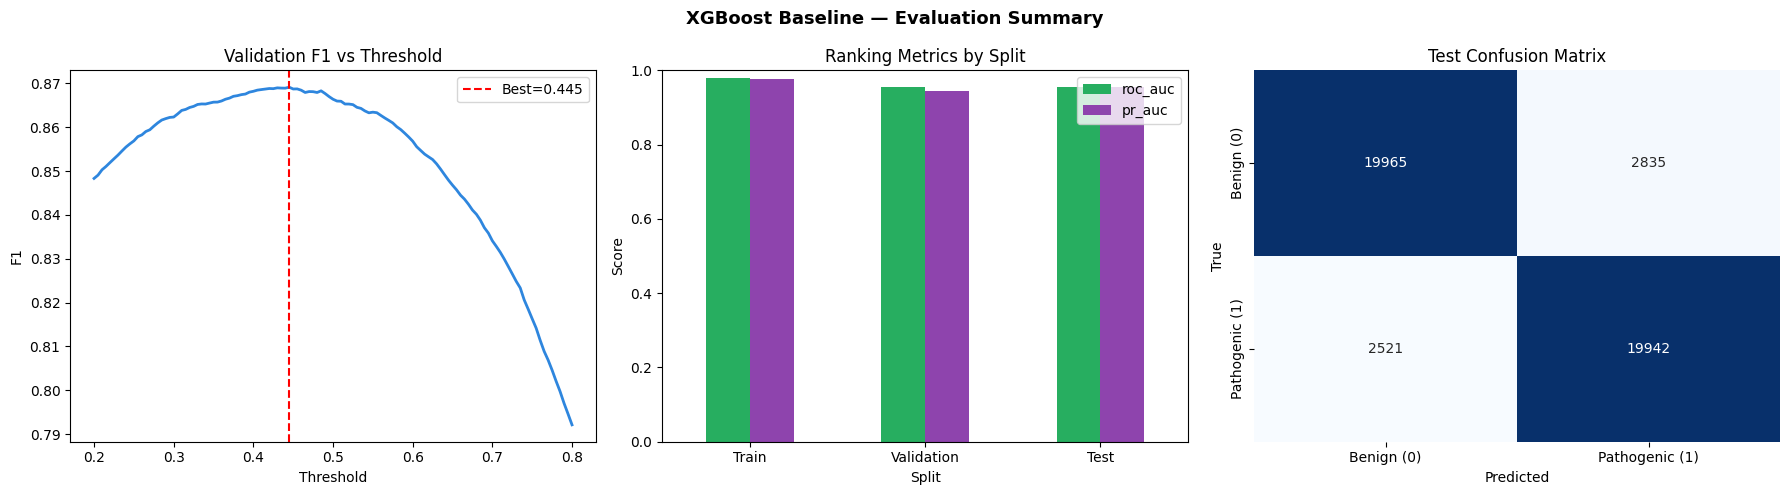

Saved: xgboost_evaluation.png


In [7]:
figures_dir = repo_root / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost Baseline — Evaluation Summary', fontsize=13, fontweight='bold')

# --- Threshold curve ---
axes[0].plot(threshold_curve['threshold'], threshold_curve['f1'], color='#2e86de', linewidth=2)
axes[0].axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.3f}')
axes[0].set_title('Validation F1 vs Threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1')
axes[0].legend()

# --- Ranking metrics bar chart ---
metrics_df.set_index('Split')[['roc_auc', 'pr_auc']].plot(
    kind='bar', ax=axes[1], color=['#27ae60', '#8e44ad']
)
axes[1].set_title('Ranking Metrics by Split')
axes[1].set_ylim(0.0, 1.0)
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=0)

# --- Test confusion matrix ---
test_prob = best_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred, labels=[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2], cbar=False)
axes[2].set_title('Test Confusion Matrix')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')
axes[2].set_xticklabels(['Benign (0)', 'Pathogenic (1)'])
axes[2].set_yticklabels(['Benign (0)', 'Pathogenic (1)'])

plt.tight_layout()
plt.savefig(figures_dir / 'xgboost_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: xgboost_evaluation.png')

In [8]:
checkpoint_dir = repo_root / 'results/checkpoints'
metrics_dir = repo_root / 'results/metrics'

checkpoint_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

model_path = checkpoint_dir / 'xgboost_best.ubj'
metrics_path = metrics_dir / 'xgboost_split_metrics.csv'
tuning_path = metrics_dir / 'xgboost_tuning_history.csv'
threshold_curve_path = metrics_dir / 'xgboost_val_threshold_curve.csv'
features_path = metrics_dir / 'xgboost_feature_columns.csv'
params_path = metrics_dir / 'xgboost_best_params.csv'

best_model.save_model(str(model_path))
metrics_df.to_csv(metrics_path, index=False)
tuning_history.to_csv(tuning_path, index=False)
threshold_curve.to_csv(threshold_curve_path, index=False)
pd.DataFrame({'encoded_feature': encoded_feature_names}).to_csv(features_path, index=False)
pd.DataFrame([{**best_params, 'best_threshold': best_threshold,
               'n_numeric_features': len(numeric_cols),
               'n_categorical_features': len(categorical_cols),
               'n_encoded_features': len(encoded_feature_names)}]).to_csv(params_path, index=False)

print('Saved artifacts:')
print('  model:   ', model_path)
print('  metrics: ', metrics_path)
print('  tuning:  ', tuning_path)
print('  curve:   ', threshold_curve_path)
print('  features:', features_path)
print('  params:  ', params_path)

Saved artifacts:
  model:    /Users/ry7vv/Documents/Coding_Project/GenticGraduationProject/results/checkpoints/xgboost_best.ubj
  metrics:  /Users/ry7vv/Documents/Coding_Project/GenticGraduationProject/results/metrics/xgboost_split_metrics.csv
  tuning:   /Users/ry7vv/Documents/Coding_Project/GenticGraduationProject/results/metrics/xgboost_tuning_history.csv
  curve:    /Users/ry7vv/Documents/Coding_Project/GenticGraduationProject/results/metrics/xgboost_val_threshold_curve.csv
  features: /Users/ry7vv/Documents/Coding_Project/GenticGraduationProject/results/metrics/xgboost_feature_columns.csv
  params:   /Users/ry7vv/Documents/Coding_Project/GenticGraduationProject/results/metrics/xgboost_best_params.csv


## Step 5: SHAP Analysis — Model Interpretability

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for every
individual prediction, grounded in cooperative game theory.

For each test sample, SHAP answers:
- **Which features** influenced the prediction?
- **In what direction** — did they push toward Pathogenic or Benign?
- **By how much** — the magnitude of the effect on the output probability.

We use `TreeExplainer`, which computes exact SHAP values for tree-based models (XGBoost)
in O(TLD²) time — much faster than the model-agnostic KernelExplainer.
Analysis is run on a random sample of 5,000 test variants.

In [9]:
import shap

# Sample 5000 from test set for speed
rng = np.random.default_rng(42)
shap_idx = rng.choice(X_test.shape[0], size=min(5000, X_test.shape[0]), replace=False)

# Convert sparse matrix to dense if needed
X_shap = X_test[shap_idx]
if hasattr(X_shap, 'toarray'):
    X_shap = X_shap.toarray()

# Build clean feature names (strip num__ / cat__ prefix added by ColumnTransformer)
clean_names = [n.replace('num__', '').replace('cat__', '') for n in encoded_feature_names]

# Compute SHAP values using TreeExplainer (fast for XGBoost)
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

print(f'SHAP computed on {X_shap.shape[0]:,} test samples')
print(f'SHAP values shape: {np.array(shap_values).shape}')

SHAP computed on 5,000 test samples
SHAP values shape: (5000, 74)


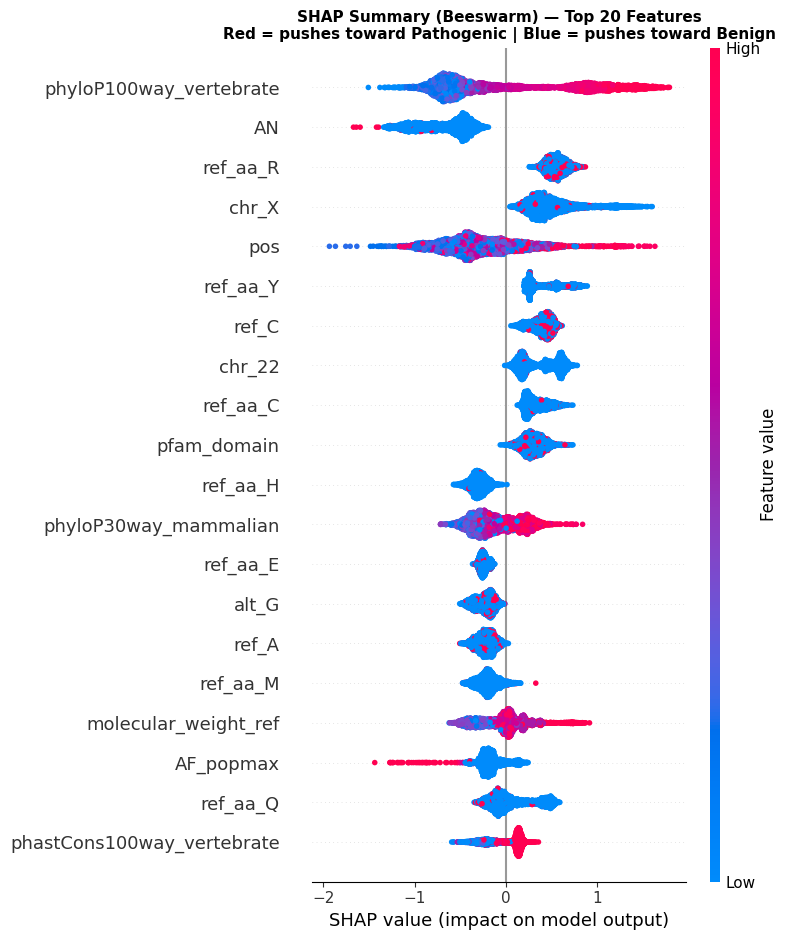

Saved: shap_summary.png


In [10]:
# Plot 1: SHAP Beeswarm (summary) — shows importance + direction per feature
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_shap,
    feature_names=clean_names,
    max_display=20,
    show=False,
    plot_type='dot',
)
plt.title('SHAP Summary (Beeswarm) — Top 20 Features\n'
          'Red = pushes toward Pathogenic | Blue = pushes toward Benign',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_summary.png')

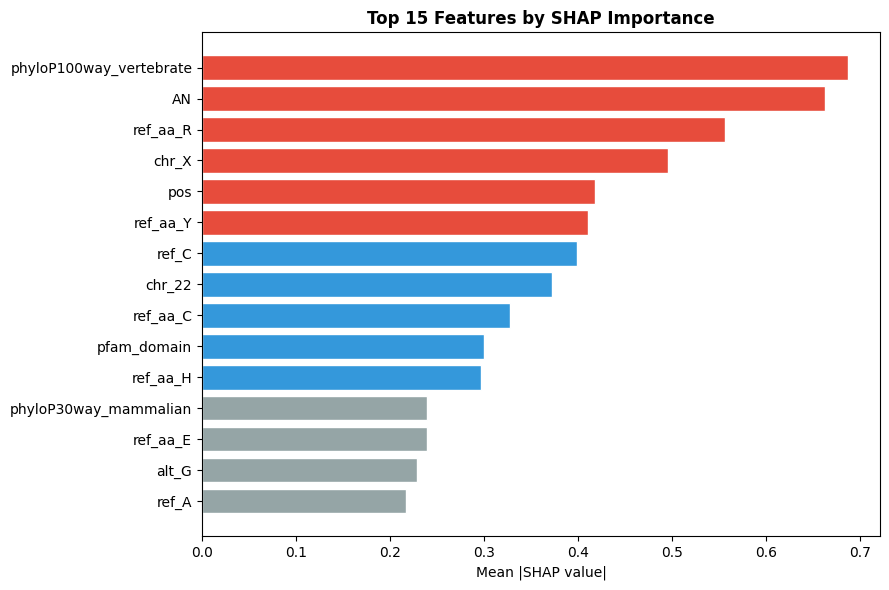

Saved: shap_bar.png

--- Top 15 Features (Mean |SHAP|) ---
                feature  mean_abs_shap
phyloP100way_vertebrate       0.687380
                     AN       0.662995
               ref_aa_R       0.556322
                  chr_X       0.496244
                    pos       0.418058
               ref_aa_Y       0.410489
                  ref_C       0.399308
                 chr_22       0.373034
               ref_aa_C       0.328063
            pfam_domain       0.300478
               ref_aa_H       0.296876
  phyloP30way_mammalian       0.239597
               ref_aa_E       0.239399
                  alt_G       0.228450
                  ref_A       0.217438


In [11]:
# Plot 2: SHAP Bar chart — top 15 features by mean |SHAP|
mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance = (
    pd.DataFrame({'feature': clean_names, 'mean_abs_shap': mean_shap})
    .sort_values('mean_abs_shap', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if i < 6 else '#3498db' if i < 11 else '#95a5a6'
          for i in range(len(shap_importance))]
ax.barh(shap_importance['feature'][::-1], shap_importance['mean_abs_shap'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top 15 Features by SHAP Importance', fontsize=12, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(figures_dir / 'shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_bar.png')

print('\n--- Top 15 Features (Mean |SHAP|) ---')
print(shap_importance.to_string(index=False))

## Step 6: Dataset Ablation — Strict vs Balanced

We evaluate the **same trained model** on two held-out test sets to measure the effect of
data quality filtering on generalization.

| Property            | Balanced (primary)        | Strict                       |
|---------------------|---------------------------|------------------------------|
| Training size       | ~283K variants            | ~37K variants                |
| Review stars        | ≥ 1 (single submitter OK) | ≥ 2 (multiple submitters)    |
| Missing values      | Median-imputed            | Dropped (no imputation)      |
| Feature columns     | 31 (includes is_imputed_*) | 40 (extra alt AA + changes) |

**Why this matters:** The Balanced dataset maximizes training data but includes lower-
confidence ClinVar submissions. The Strict dataset is higher quality but smaller.
Evaluating the same model on both test sets shows whether training on noisy labels
hurts performance on clean-label test data.

In [12]:
# Load strict splits
strict_train = pd.read_parquet(repo_root / 'data/splits/strict/train.parquet')
strict_val   = pd.read_parquet(repo_root / 'data/splits/strict/val.parquet')
strict_test  = pd.read_parquet(repo_root / 'data/splits/strict/test.parquet')

print('Strict splits:')
for name, df in [('train', strict_train), ('val', strict_val), ('test', strict_test)]:
    p = int((df['label']==1).sum())
    b = int((df['label']==0).sum())
    print(f'  {name}: {len(df):>6,} rows | {p:,} pathogenic ({p/len(df)*100:.1f}%) | {df["gene"].nunique():,} genes')

# Strict data doesn't have the imputation flags — add them as 0 (no imputation applied)
imputation_flags = [c for c in numeric_cols if c.startswith('is_imputed_')]
for flag in imputation_flags:
    for df in (strict_train, strict_val, strict_test):
        if flag not in df.columns:
            df[flag] = 0

# Use the SAME fitted preprocessor from balanced training — DO NOT re-fit on strict data.
# Re-fitting would produce different OHE columns (different rare categories → different col count).
selected = numeric_cols + categorical_cols

def _prep_df(df, num_cols, cat_cols):
    """Apply same numeric + categorical cleaning used in prepare_with_encoding."""
    X = df[num_cols + cat_cols].copy()
    X[num_cols] = X[num_cols].replace([np.inf, -np.inf], np.nan)
    medians = X_train_df[num_cols].median(numeric_only=True)   # balanced medians
    X[num_cols] = X[num_cols].fillna(medians)
    for c in cat_cols:
        X[c] = X[c].fillna('MISSING').astype(str)
    return X

# Re-use balanced training medians (stored in train_df before encoding)
X_train_df = train_df[numeric_cols + categorical_cols].copy()
X_train_df[numeric_cols] = X_train_df[numeric_cols].replace([np.inf, -np.inf], np.nan)

X_strict_test_df  = _prep_df(strict_test,  numeric_cols, categorical_cols)
X_strict_val_df   = _prep_df(strict_val,   numeric_cols, categorical_cols)
X_strict_train_df = _prep_df(strict_train, numeric_cols, categorical_cols)

# Transform using the already-fitted balanced preprocessor (handle_unknown='ignore' handles new categories)
X_strict_train = balanced_preprocessor.transform(X_strict_train_df)
X_strict_val   = balanced_preprocessor.transform(X_strict_val_df)
X_strict_test  = balanced_preprocessor.transform(X_strict_test_df)

y_strict_train = strict_train['label'].astype(int)
y_strict_val   = strict_val['label'].astype(int)
y_strict_test  = strict_test['label'].astype(int)

print(f'\nEncoded: {X_strict_test.shape[1]} features (balanced: {X_test.shape[1]})')

Strict splits:
  train: 26,079 rows | 7,586 pathogenic (29.1%) | 4,619 genes
  val:  6,257 rows | 1,732 pathogenic (27.7%) | 990 genes
  test:  5,334 rows | 1,717 pathogenic (32.2%) | 990 genes



Encoded: 74 features (balanced: 74)


--- Balanced Model: Strict vs Balanced Test ---
                    Dataset     N  ROC-AUC  PR-AUC     F1    MCC  Balanced Acc
Balanced test  (283K train) 45263   0.9548  0.9544 0.8816 0.7634        0.8817
 Strict test    (37K train)  5334   0.9499  0.9096 0.8171 0.7252        0.8747


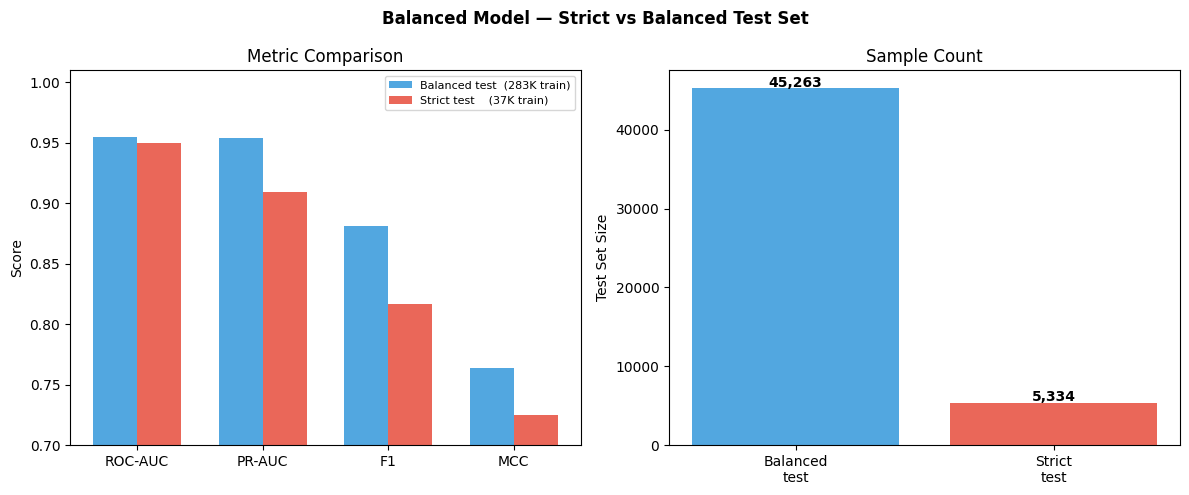

Saved: ablation_strict_vs_balanced.png


In [13]:
# Evaluate balanced model on BOTH test sets
ablation_rows = []
for label, X, y in [
    ('Balanced test  (283K train)', X_test,        y_test),
    ('Strict test    (37K train)',  X_strict_test,  y_strict_test),
]:
    prob = best_model.predict_proba(X)[:, 1]
    m = compute_classification_metrics(y, prob, threshold=best_threshold)
    ablation_rows.append({
        'Dataset':          label,
        'N':                len(y),
        'ROC-AUC':          round(m['roc_auc'], 4),
        'PR-AUC':           round(m['pr_auc'], 4),
        'F1':               round(m['f1'], 4),
        'MCC':              round(m['mcc'], 4),
        'Balanced Acc':     round(m['balanced_accuracy'], 4),
    })

ablation_df = pd.DataFrame(ablation_rows)
print('--- Balanced Model: Strict vs Balanced Test ---')
print(ablation_df.to_string(index=False))

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Balanced Model — Strict vs Balanced Test Set', fontsize=12, fontweight='bold')

metrics_to_plot = ['ROC-AUC', 'PR-AUC', 'F1', 'MCC']
x = np.arange(len(metrics_to_plot))
w = 0.35
colors_ab = ['#3498db', '#e74c3c']

for i, row in ablation_df.iterrows():
    vals = [row[m] for m in metrics_to_plot]
    axes[0].bar(x + (i - 0.5) * w, vals, w, label=row['Dataset'].strip(), color=colors_ab[i], alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylim(0.7, 1.01)
axes[0].set_ylabel('Score')
axes[0].set_title('Metric Comparison')
axes[0].legend(fontsize=8)

# Sample size comparison
axes[1].bar(['Balanced\ntest', 'Strict\ntest'],
            [len(y_test), len(y_strict_test)],
            color=colors_ab, alpha=0.85)
axes[1].set_ylabel('Test Set Size')
axes[1].set_title('Sample Count')
for j, v in enumerate([len(y_test), len(y_strict_test)]):
    axes[1].text(j, v + 200, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(figures_dir / 'ablation_strict_vs_balanced.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_strict_vs_balanced.png')

## Step 7: Feature Group Ablation — Contribution of Each Feature Family

We train four lightweight XGBoost models (`n_estimators=100`) on the balanced training
set, each using a different subset of features. Comparing validation ROC-AUC isolates the
contribution of each feature group.

| Model | Feature Group | Features Included |
|-------|---------------|-------------------|
| A | Conservation only | phyloP100way, phyloP30way, phastCons100way, phastCons30way, GERP++\_RS, GERP++\_NR |
| B | AA Properties only | hydrophobicity\_ref, molecular\_weight\_ref, volume\_ref, polarity\_ref, charge\_ref |
| C | No Allele Frequency | All features except AC, log\_AF, is\_common, AF\_popmax, AN |
| D | All features (baseline) | Full 22 numeric + 4 categorical — replicated from the tuned model |

A large drop from D→C indicates allele frequency is essential.
A large drop from D→A shows that conservation alone is almost sufficient.
Model B shows the marginal value of amino acid physicochemical properties.

In [14]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score

CONSERVATION_FEATS = [
    'phyloP100way_vertebrate', 'phyloP30way_mammalian',
    'phastCons100way_vertebrate', 'phastCons30way_mammalian',
    'GERP++_RS', 'GERP++_NR',
]
AA_FEATS = [
    'hydrophobicity_ref', 'molecular_weight_ref',
    'volume_ref', 'polarity_ref', 'charge_ref',
]
AF_FEATS = ['AC', 'log_AF', 'is_common', 'AF_popmax', 'AN']

def run_group_ablation(train_df, val_df, num_feats, cat_feats, label):
    """Train a quick XGBoost (100 trees) and return val ROC-AUC."""
    Xtr, Xval, _, _, _ = prepare_with_encoding(
        train_df, val_df, val_df,   # pass val as test too (unused)
        num_feats, cat_feats
    )
    ytr  = train_df['label'].astype(int)
    yval = val_df['label'].astype(int)

    pos = int((ytr == 1).sum())
    neg = int((ytr == 0).sum())
    spw = neg / max(pos, 1)

    clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=spw,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0,
    )
    clf.fit(Xtr, ytr, verbose=False)
    val_prob = clf.predict_proba(Xval)[:, 1]
    auc = roc_auc_score(yval, val_prob)
    print(f'  {label}: ROC-AUC = {auc:.4f}  (features: {Xtr.shape[1]})')
    return auc

print('Training 4 ablation models (n_estimators=100 each)...\n')

# A: Conservation only (numeric only)
no_af_numeric = [c for c in numeric_cols if c not in AF_FEATS]

group_results = {}

group_results['A: Conservation'] = run_group_ablation(
    train_df, val_df,
    [c for c in CONSERVATION_FEATS if c in numeric_cols], [],
    'A: Conservation only'
)
group_results['B: AA Properties'] = run_group_ablation(
    train_df, val_df,
    [c for c in AA_FEATS if c in numeric_cols], [],
    'B: AA Properties only'
)
group_results['C: No AF'] = run_group_ablation(
    train_df, val_df,
    [c for c in numeric_cols if c not in AF_FEATS], categorical_cols,
    'C: All except Allele Frequency'
)
group_results['D: All (baseline)'] = run_group_ablation(
    train_df, val_df,
    numeric_cols, categorical_cols,
    'D: All features (baseline)'
)

Training 4 ablation models (n_estimators=100 each)...



  A: Conservation only: ROC-AUC = 0.8398  (features: 6)


  B: AA Properties only: ROC-AUC = 0.8038  (features: 5)


  C: All except Allele Frequency: ROC-AUC = 0.9464  (features: 69)


  D: All features (baseline): ROC-AUC = 0.9498  (features: 74)


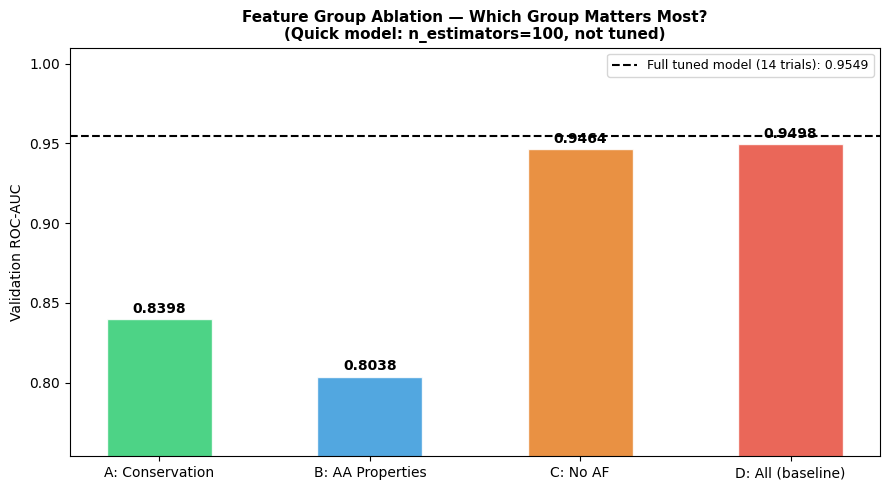

Saved: ablation_feature_groups.png

--- Feature Group Ablation Summary ---
            Model  Val ROC-AUC  vs Full Model
  A: Conservation       0.8398        -0.1151
 B: AA Properties       0.8038        -0.1510
         C: No AF       0.9464        -0.0085
D: All (baseline)       0.9498        -0.0050

Saved: results/metrics/ablation_feature_groups.csv


In [15]:
# Bar chart: feature group ROC-AUC
group_colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
labels = list(group_results.keys())
aucs   = list(group_results.values())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, aucs, color=group_colors, alpha=0.85, edgecolor='white', width=0.5)

# Add the full tuned model result for reference
full_auc = metrics_df.loc[metrics_df['Split'] == 'Validation', 'roc_auc'].values[0]
ax.axhline(full_auc, color='black', linestyle='--', linewidth=1.5,
           label=f'Full tuned model (14 trials): {full_auc:.4f}')

for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(max(0, min(aucs) - 0.05), 1.01)
ax.set_ylabel('Validation ROC-AUC')
ax.set_title('Feature Group Ablation — Which Group Matters Most?\n'
             '(Quick model: n_estimators=100, not tuned)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(figures_dir / 'ablation_feature_groups.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_feature_groups.png')

# Summary table
ablation_group_df = pd.DataFrame({
    'Model': labels,
    'Val ROC-AUC': [round(v, 4) for v in aucs],
    'vs Full Model': [round(v - full_auc, 4) for v in aucs],
})
print('\n--- Feature Group Ablation Summary ---')
print(ablation_group_df.to_string(index=False))
ablation_group_df.to_csv(repo_root / 'results/metrics/ablation_feature_groups.csv', index=False)
print('\nSaved: results/metrics/ablation_feature_groups.csv')